## standard scaler


#### Formula:

z =
𝑥
−
𝜇
/
𝜎

#### Effect:

Transforms data so that it has mean = 0 and standard deviation = 1.

Values are expressed in terms of “how many standard deviations away from the mean” they are.


### When to Use Standardization
Distance-based algorithms

KNN, K-means clustering, SVM

These rely on distance calculations. Standardization ensures all features contribute equally, regardless of scale.

Gradient-based algorithms

Logistic regression, linear regression, neural networks

Standardization speeds up convergence because features are centered around 0 with unit variance.

Principal Component Analysis (PCA)

PCA is sensitive to feature scales. Standardization ensures that variance is measured fairly across features.

Datasets with different units

Example: Age (years) vs. Income (dollars). Without standardization, income dominates due to larger numeric values.

Gaussian assumptions

Many statistical models assume features follow a normal distribution. Standardization helps approximate this by centering and scaling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv(r"C:\Users\pc\Downloads\Social_Network_Ads.csv",index_col ="User ID")
data


,Gender,Age,EstimatedSalary,Purchased
User ID,,,,
15624510,Male,19,19000,0
15810944,Male,35,20000,0
15668575,Female,26,43000,0
15603246,Female,27,57000,0
15804002,Male,19,76000,0
...,...,...,...,...
15691863,Female,46,41000,1
15706071,Male,51,23000,1
15654296,Female,50,20000,1


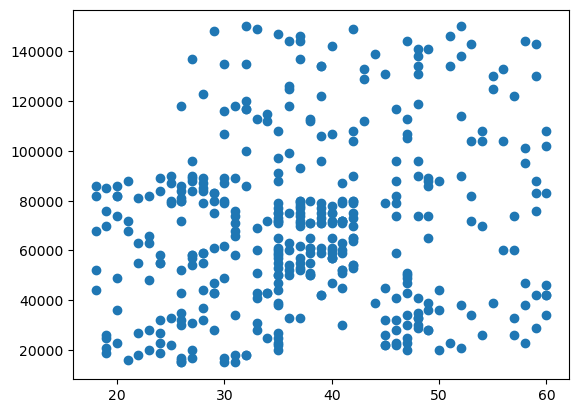

In [2]:
before = plt.scatter(data = data, x = "Age",y = "EstimatedSalary")

In [3]:
data = data.replace({"Male": 1,"Female": 0})
data

C:\Users\pc\AppData\Local\Temp\ipykernel_9100\2538706710.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({"Male": 1,"Female": 0})


,Gender,Age,EstimatedSalary,Purchased
User ID,,,,
15624510,1,19,19000,0
15810944,1,35,20000,0
15668575,0,26,43000,0
15603246,0,27,57000,0
15804002,1,19,76000,0
...,...,...,...,...
15691863,0,46,41000,1
15706071,1,51,23000,1
15654296,0,50,20000,1


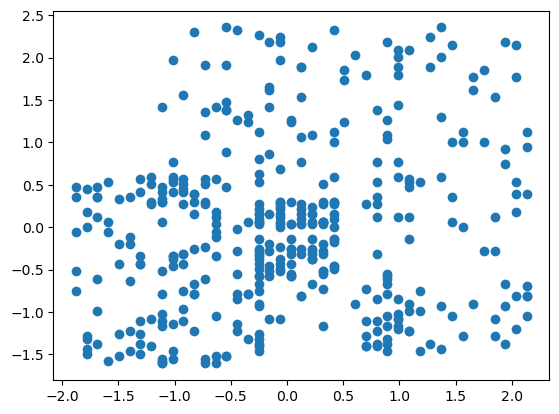

In [ ]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
scaled =  pd.DataFrame(std.fit_transform(data),columns = data.columns)
after = plt.scatter(scaled["Age"],scaled["EstimatedSalary"])

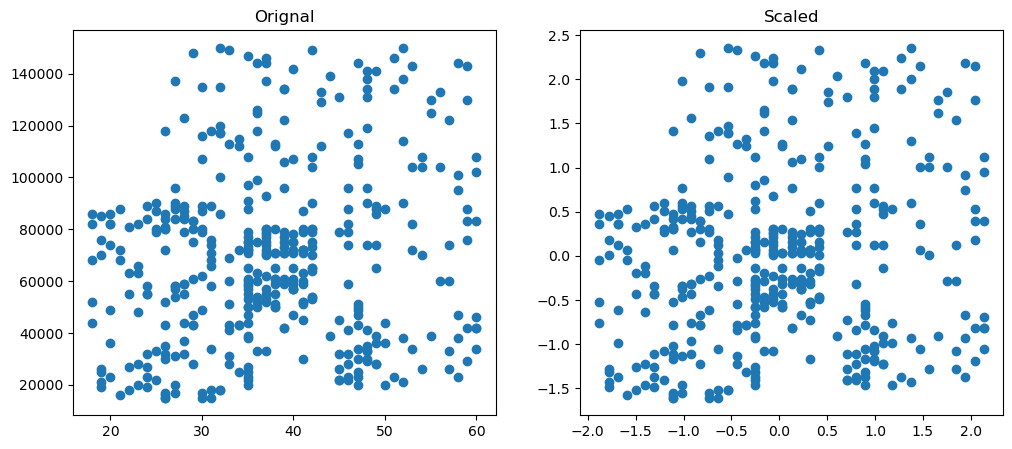

In [29]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize = (12,5))
ax1.scatter(data = data , x = "Age", y = "EstimatedSalary")
ax1.set_title("Orignal")
ax2.scatter(data = scaled, x = "Age", y = "EstimatedSalary")
ax2.set_title("Scaled")
plt.show()

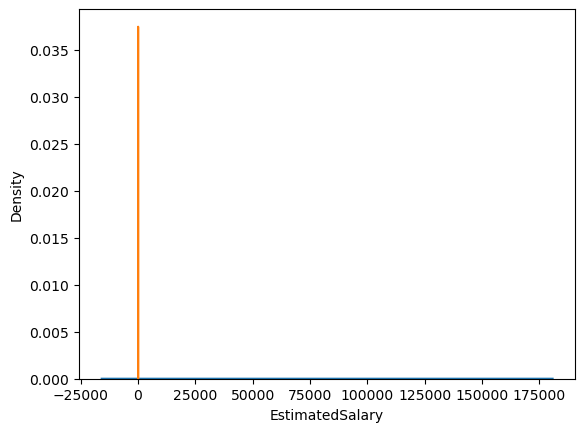

In [67]:
import seaborn as sns
sns.kdeplot(data = data,x = "EstimatedSalary")
ax1.set_title("Estimatedsalary")
sns.kdeplot(data = data,x = "Age")
ax2.set_title("Age")

plt.show()


<Axes: xlabel='EstimatedSalary', ylabel='Density'>

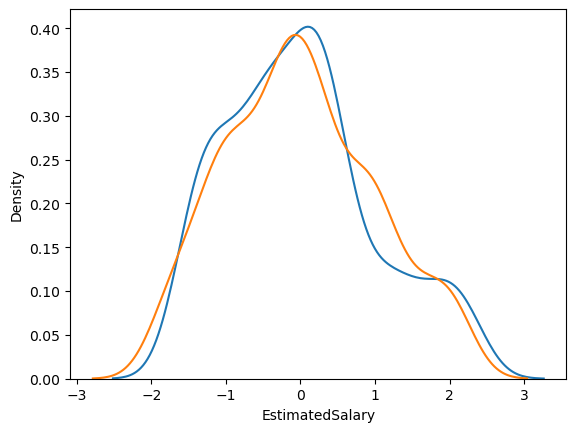

In [ ]:
sns.kdeplot(data = scaled , x = "EstimatedSalary")
sns.kdeplot(data = scaled, x = "Age")

## MIN-MAX scaling

Min-Max Scaling
Formula: 
(
𝑥
−
𝑥
𝑚
𝑖
𝑛
)
/
(
𝑥
𝑚
𝑎
𝑥
−
𝑥
𝑚
𝑖
𝑛
)

Effect: Rescales values into a fixed range, usually [0,1] or [-1,1].

Use case: Best when you need bounded values (e.g., neural networks, image pixel scaling).

Weakness: Very sensitive to outliers — one extreme value can squash everything else.

## Max-Absolute Scaling

Max-Abs Scaling
Formula: 
𝑥
/
∣
𝑥
𝑚
𝑎
𝑥
∣

Effect: Scales values to [-1,1] based on the maximum absolute value.

Use case: Works well with sparse data (like TF-IDF vectors in text mining) because it doesn’t shift/center values.

Weakness: Still sensitive to outliers.

## Mean-Normalisation

Formula: 
(
𝑥
−
mean
)
/
(
𝑥
𝑚
𝑎
𝑥
−
𝑥
𝑚
𝑖
𝑛
)

Effect: Centers values around the mean and scales them into roughly [-1,1].

Use case: Useful when you want features centered around zero but still bounded.

Weakness: Sensitive to outliers, since it uses min and max.

## Robust Scaling

Formula: 
(
𝑥
−
median
)
/
𝐼
𝑄
𝑅
, where 
𝐼
𝑄
𝑅
=
𝑄
3
−
𝑄
1

Effect: Centers data around the median and scales by the interquartile range.

Use case: Ideal for datasets with outliers or skewed distributions (e.g., salaries, financial data).

Strength: Resistant to outliers because it uses median and IQR instead of mean and standard deviation.